# 0. Cargar datos

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [97]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_839/3745035006.py:3: DtypeWarning: Columns (0: dscto_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,43440,10860.000,0,SUR 3,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,TOCINOS,...,39366,10935.000,7,SUR 3,PUNTA ARENAS,11313.0,NaN,NaN,NaN,NaN
2,2025,1,MY,ZV01,2025-01-02,1173743,NaN,38,OTROS MAYORISTAS,TOCINOS,...,321040,8026.000,9146,NORTE 2,LA SERENA,8791.0,-3.0,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1003766,NaN,32,COBERTURA,MORTADELAS,...,10860,3620.000,8790,NORTE 2,LA SERENA,3749.0,NaN,NaN,NaN,NaN
4,2025,1,MY,ZV01,2025-01-02,1037307,NaN,57,MAYORISTA B VOLUMEN,VIENESAS,...,36938,2308.625,6303,SUR 2,CHILLAN,2456.0,-6.0,NaN,NaN,NaN


In [98]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto'],
      dtype='str')

In [99]:
ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
# - Cobertura
# - Volumen Cobertura
# - Mayoristas Cadenas
# - Mayorista B Volumen
# - Otros Mayoristas
# - Horeca Volumen
# - Otros Horeca
# Pero llevan estos nombres en el df:
# <StringArray>
# [          'COBERTURA',        'OTROS HORECA',   'VOLUMEN COBERTURA',
#  'HR ACUERDOS COMERC.', 'MAYORISTA B VOLUMEN',      'HORECA VOLUMEN',
#   'HR CUENTAS CLAVES.',    'OTROS MAYORISTAS',  'MAYORISTAS CADENAS',
#          'CHILECOMPRA']
# Length: 10, dtype: str
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 10364933


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,43440,10860.000,0,SUR 3,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,TOCINOS,...,39366,10935.000,7,SUR 3,PUNTA ARENAS,11313.0,NaN,NaN,NaN,NaN
2,2025,1,MY,ZV01,2025-01-02,1173743,NaN,38,OTROS MAYORISTAS,TOCINOS,...,321040,8026.000,9146,NORTE 2,LA SERENA,8791.0,-3.0,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1003766,NaN,32,COBERTURA,MORTADELAS,...,10860,3620.000,8790,NORTE 2,LA SERENA,3749.0,NaN,NaN,NaN,NaN
4,2025,1,MY,ZV01,2025-01-02,1037307,NaN,57,MAYORISTA B VOLUMEN,VIENESAS,...,36938,2308.625,6303,SUR 2,CHILLAN,2456.0,-6.0,NaN,NaN,NaN


In [100]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado", "Zona",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,11538.0
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,11313.0
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,8791.0
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,3749.0
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,2456.0


In [101]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente                 0
Cod Canal Comercial       199
Cod Consolidado             0
Zona                   512593
Fecha Factura               0
Cod SKU                     0
Nombre SKU                  0
Monto Real                  0
Kilo Real                   0
Precio                      6
Precio_Lista              151
dtype: int64


In [102]:
ventas[ventas["Cod Canal Comercial"].isna()].head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
43435,1234854,NaN,55,SANTIAGO,2025-12-10,3044,SALAME PIEZA LP,7625,0.95,8026.315789,12800.0
183084,1238287,NaN,37,SUR 3,2025-12-30,2288,PAPAS FRITAS 10x1 KG SJ,21980,10.00,2198.000000,3400.0
262323,1234854,NaN,55,SANTIAGO,2025-12-10,1053,VIENESA 17 CM CALIBRE 28 SJ,180166,68.40,2634.005848,4200.0
749078,1237358,NaN,32,NORTE 1,2025-12-10,6006,MARGARINA QUALY CON SAL 24x250G,22339,6.00,3723.166667,6400.0
822818,1237548,NaN,32,NaN,2025-12-13,6006,MARGARINA QUALY CON SAL 24x250G,22338,6.00,3723.000000,6400.0


In [103]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante
ventas = ventas.dropna(subset=cols_relevantes_ventas)

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 10364933 filas y 11 columnas antes de filtrar.
El dataframe tiene 9852085 filas y 11 columnas después de filtrar.


## 0.2. Maestro SKUs

In [104]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [105]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 0.3 Zonales

In [106]:
path_info_zonales = "datos/Clientes - Zonales.xlsx"
zonales = pd.read_excel(path_info_zonales)
zonales.head()

,Id cliente,REGIONES
0,1194043,RANCAGUA
1,1155918,RANCAGUA
2,1090050,RANCAGUA
3,1203751,RANCAGUA
4,1231602,IQUIQUE


In [107]:
zonales.columns

Index(['Id cliente', 'REGIONES'], dtype='str')

# 1. Cruzar bases

In [108]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado", "zona",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]

In [109]:
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,11538.0,2025,1,0.10,False,40.0
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,11313.0,2025,1,0.18,False,20.0
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,8791.0,2025,1,0.50,False,80.0
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,3749.0,2025,1,3.00,False,1.0
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,2456.0,2025,1,1.00,False,16.0


In [110]:
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()

inconsistencia
False    9851841
True         244
Name: count, dtype: int64

In [111]:
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
20063,1180300,CB,32,NORTE 1,2025-01-03,151,CHORIZO 12X250 GR SJ,8,0.003,2666.666667,3620.0,2025,1,0.25,False,0.012000,False,True
76948,1134236,CB,32,SUR 2,2025-05-30,6772,DESPUNTE QUESO MANTECOSO 5 KG,21218,4.460,4757.399103,5947.0,2025,5,5.00,False,0.892000,False,True
79775,52847,MY,57,SANTIAGO,2025-08-25,8284,MORTADELA LISA 3 KGS WI,43091,19.700,2187.360406,2327.0,2025,8,3.00,False,6.566667,False,True
144472,1033697,MY,57,NORTE 2,2025-03-24,3032,SALCHICHON CERVEZA LP,924,0.200,4620.000000,4913.0,2025,3,2.50,False,0.080000,False,True
144664,1033697,MY,57,NORTE 2,2025-03-24,3032,SALCHICHON CERVEZA LP,924,0.200,4620.000000,4913.0,2025,3,2.50,False,0.080000,False,True


In [112]:
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,11538.0,2025,1,0.10,False,40.0,True,False
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,11313.0,2025,1,0.18,False,20.0,True,False
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,8791.0,2025,1,0.50,False,80.0,True,False
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,3749.0,2025,1,3.00,False,1.0,True,False
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,2456.0,2025,1,1.00,False,16.0,True,False


In [113]:
# Agregar zonal a ventas Index(['Id cliente', 'REGIONES'], dtype='str')
ventas = ventas.merge(zonales[["Id cliente", "REGIONES"]].rename(columns={"Id cliente": "cod_cliente", "REGIONES": "zonal"}), on="cod_cliente", how="left")

# 2. Dispersión

In [114]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

In [115]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,...,2025,1,0.10,False,40.0,True,False,PUNTA ARENAS,1086.000,1153.80
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,...,2025,1,0.18,False,20.0,True,False,PUNTA ARENAS,1968.300,2036.34
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,...,2025,1,0.50,False,80.0,True,False,LA SERENA,4013.000,4395.50
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,...,2025,1,3.00,False,1.0,True,False,LA SERENA,10860.000,11247.00
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,...,2025,1,1.00,False,16.0,True,False,CHILLAN,2308.625,2456.00


In [116]:
# Calcular precio promedio por unidad para cada SKU-mes-año usando Fecha Factura
precio_promedio_por_unidad = ventas.groupby(["cod_sku", "mes_factura", "año_factura"])["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad.head()

,cod_sku,mes_factura,año_factura,precio_promedio_por_unidad
0,20,1,2025,15455.607557
1,20,1,2026,15435.326496
2,20,2,2025,15465.393058
3,20,2,2026,14638.982083
4,20,3,2025,15476.324111


In [117]:
# Calcular desviación porcentual del precio por unidad respecto al precio promedio para cada venta según SKU-mes-año de Fecha Factura
ventas = ventas.merge(precio_promedio_por_unidad, on=["cod_sku", "mes_factura", "año_factura"], how="left")
ventas["desviacion_porcentual_precio_por_unidad"] = (ventas["precio_por_unidad"] - ventas["precio_promedio_por_unidad"]) / ventas["precio_promedio_por_unidad"] * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,...,0.10,False,40.0,True,False,PUNTA ARENAS,1086.000,1153.80,1095.284329,-0.847664
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,...,0.18,False,20.0,True,False,PUNTA ARENAS,1968.300,2036.34,1823.907855,7.916636
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,...,0.50,False,80.0,True,False,LA SERENA,4013.000,4395.50,4350.372971,-7.755036
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,...,3.00,False,1.0,True,False,LA SERENA,10860.000,11247.00,11190.369729,-2.952268
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,...,1.00,False,16.0,True,False,CHILLAN,2308.625,2456.00,2280.189304,1.247076


## 2.1 Dispersión e Importancia por SKU

### 2.1.1 Armar tablas

In [118]:
# Calcular ingreso total por SKU
ingreso_por_sku = ventas.groupby("cod_sku")["monto_real"].sum().reset_index().rename(columns={"monto_real": "ingreso_total"})
ingreso_por_sku.head()

,cod_sku,ingreso_total
0,20,2019157261
1,27,194038716
2,30,1248961005
3,102,402510974
4,151,517552214


In [119]:
# Calcular precio promedio por unidad para cada SKU
precio_promedio_por_unidad_sku = ventas.groupby("cod_sku")["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad_sku.head()

,cod_sku,precio_promedio_por_unidad
0,20,15408.872502
1,27,15798.436804
2,30,7133.108407
3,102,835.646174
4,151,894.896026


In [120]:
# Calcular tabla de dispersión de precio por unidad para cada SKU:
#   - desviación estándar
#   - iqr
desviacion_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].std().reset_index().rename(columns={"precio_por_unidad": "desviacion_precio_por_unidad"})
iqr_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index().rename(columns={"precio_por_unidad": "iqr_precio_por_unidad"})

# Combinar las tablas
dispersion_sku = desviacion_precio_por_unidad.merge(iqr_precio_por_unidad, on="cod_sku")
dispersion_sku.sort_values("desviacion_precio_por_unidad", ascending=False).head()
dispersion_sku.head()

,cod_sku,desviacion_precio_por_unidad,iqr_precio_por_unidad
0,20,514.622994,2.897283
1,27,652.553601,480.494203
2,30,260.653938,1.191280
3,102,38.991728,0.083333
4,151,33.103427,0.083333


In [121]:
# Armar tabla con SKU, promedio por sku, medidas de dispersión, ingreso total y multiplicaciones de medidas de dispersión por ingreso total
tabla_sku = precio_promedio_por_unidad_sku.merge(dispersion_sku, on="cod_sku").merge(ingreso_por_sku, on="cod_sku")
tabla_sku["desviacion_por_unidad_por_ingreso"] = tabla_sku["desviacion_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku["iqr_por_unidad_por_ingreso"] = tabla_sku["iqr_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku.head()

,cod_sku,precio_promedio_por_unidad,desviacion_precio_por_unidad,iqr_precio_por_unidad,ingreso_total,desviacion_por_unidad_por_ingreso,iqr_por_unidad_por_ingreso
0,20,15408.872502,514.622994,2.897283,2019157261,1.039105e+12,5.850071e+09
1,27,15798.436804,652.553601,480.494203,194038716,1.266207e+11,9.323448e+10
2,30,7133.108407,260.653938,1.191280,1248961005,3.255466e+11,1.487862e+09
3,102,835.646174,38.991728,0.083333,402510974,1.569460e+10,3.354258e+07
4,151,894.896026,33.103427,0.083333,517552214,1.713275e+10,4.312935e+07


In [122]:
# Tabla Resumen: SKU, nombre, precio promedio, relevancia (iqr_por_unidad_por_ingreso)
tabla_resumen = tabla_sku.merge(maestro[["cod_sku", "texto_breve_material"]], on="cod_sku", how="left")[["cod_sku", "texto_breve_material", "precio_promedio_por_unidad", "iqr_por_unidad_por_ingreso"]]
tabla_resumen.sort_values("iqr_por_unidad_por_ingreso", ascending=False).head()
tabla_resumen.head()

,cod_sku,texto_breve_material,precio_promedio_por_unidad,iqr_por_unidad_por_ingreso
0,20,ARROLLADO LOMO CON AJI SJ,15408.872502,5.850071e+09
1,27,ARROLLADO LOMO SIN AJI SJ,15798.436804,9.323448e+10
2,30,ARROLLADO HUASO CON AJI SJ,7133.108407,1.487862e+09
3,102,ARROLLADO LOMO CON AJI 12X150 GR SJ,835.646174,3.354258e+07
4,151,CHORIZO 12X250 GR SJ,894.896026,4.312935e+07


### 2.1.2. Gráficos

SKUs más importantes: [3003 3239 1372 3456 3313 1834 6770 1228 3032 3947 3018 3109 3243 8508
 8213  210 8300 3017 3001 3256]


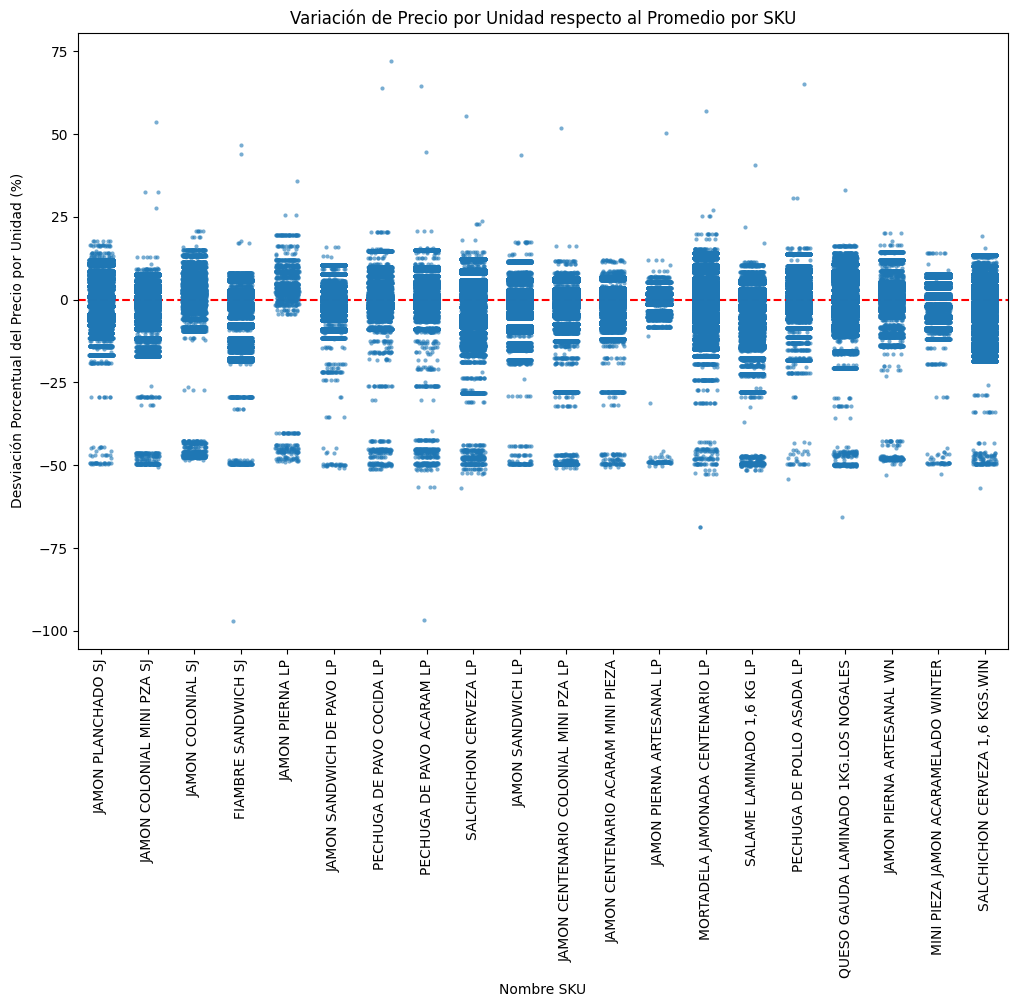

In [123]:
# Graficar  variación de precio unitario c/r a precio promedio (como porcentaje) agrupando por SKU
# Tomamos desviacion para cada sku
datos_grafico = ventas[["cod_sku", "nombre_sku", "cod_canal_comercial", "desviacion_porcentual_precio_por_unidad"]].copy()

# Filtrar ventas con desviación porcentual extrema (ej. > 100% o < -100%) para evitar distorsionar el gráfico
datos_grafico = datos_grafico[(datos_grafico["desviacion_porcentual_precio_por_unidad"] < 100) & (datos_grafico["desviacion_porcentual_precio_por_unidad"] > -100)]

# Filtrar y dejar sólo 20 SKUs con más importancia (desviacion_por_unidad_por_ingreso) para visualizar
skus_mas_importantes = tabla_sku.sort_values("desviacion_por_unidad_por_ingreso", ascending=False).head(20)["cod_sku"]
print("SKUs más importantes:", skus_mas_importantes.values)
datos_grafico = datos_grafico[datos_grafico["cod_sku"].isin(skus_mas_importantes)]
datos_grafico["cod_sku_cat"] = datos_grafico["cod_sku"].astype(str)
orden_skus = sorted(datos_grafico["cod_sku_cat"].unique())
nombre_por_cat = datos_grafico[["cod_sku_cat", "nombre_sku"]].drop_duplicates(subset=["cod_sku_cat"]).set_index("cod_sku_cat")["nombre_sku"]
etiquetas_x = [nombre_por_cat.get(cod, cod) for cod in orden_skus]

plt.figure(figsize=(12, 8))
ax = sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_grafico, order=orden_skus, jitter=0.25, alpha=0.6, size=3)
plt.axhline(0, color="red", linestyle="--")                     # Agregar linea punteada en y=0 para referencia
plt.title("Variación de Precio por Unidad respecto al Promedio por SKU")
plt.xlabel("Nombre SKU")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(ticks=range(len(orden_skus)), labels=etiquetas_x, rotation=90)
plt.show()

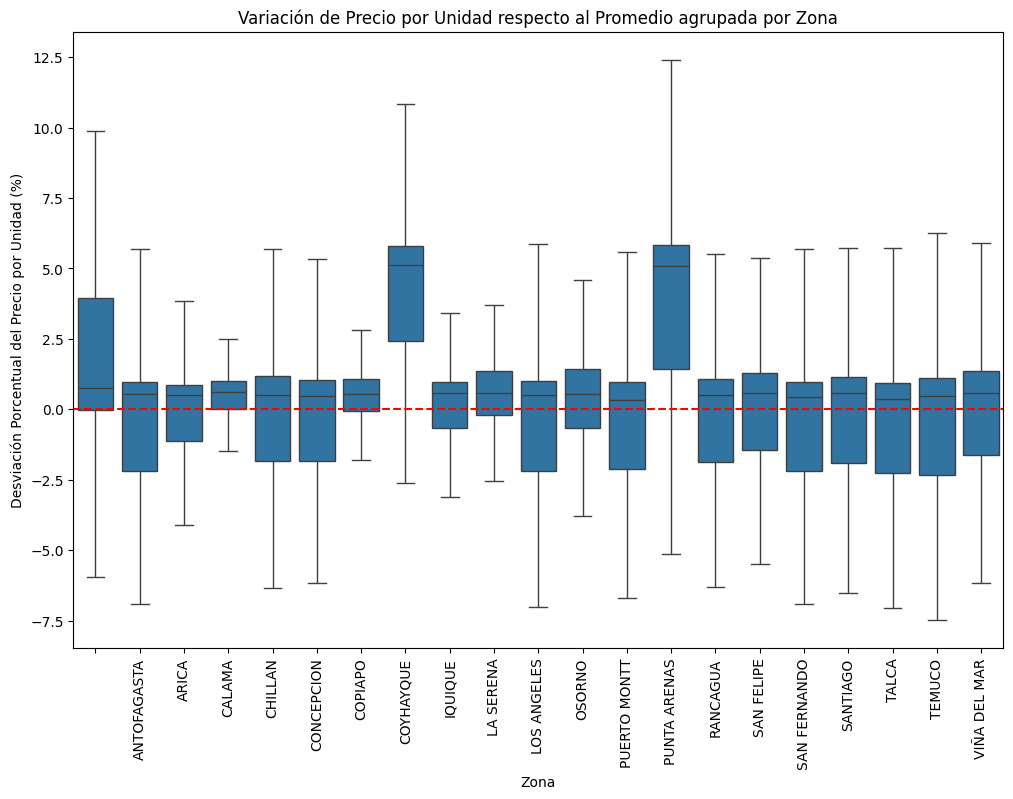

In [124]:
# Graficar variación de precio unitario c/r a precio promedio (como porcentaje) agrupando por Zona

datos_grafico = ventas[["zonal", "desviacion_porcentual_precio_por_unidad"]].copy()

# Filtrar ventas con desviación porcentual extrema para evitar distorsionar el gráfico
datos_grafico = datos_grafico[
    (datos_grafico["desviacion_porcentual_precio_por_unidad"] < 100) &
    (datos_grafico["desviacion_porcentual_precio_por_unidad"] > -100)
]

# Convertir Zona a string por seguridad
datos_grafico["zonal"] = datos_grafico["zonal"].astype(str)

# Definir orden de zonas
orden_zonas = sorted(datos_grafico["zonal"].dropna().unique())

plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    x="zonal",
    y="desviacion_porcentual_precio_por_unidad",
    data=datos_grafico,
    order=orden_zonas,
    showfliers=False,
    #jitter=0.25,
    #alpha=0.6,
    #size=3
)

plt.axhline(0, color="red", linestyle="--")
plt.title("Variación de Precio por Unidad respecto al Promedio agrupada por Zona")
plt.xlabel("Zona")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(rotation=90)
plt.show()

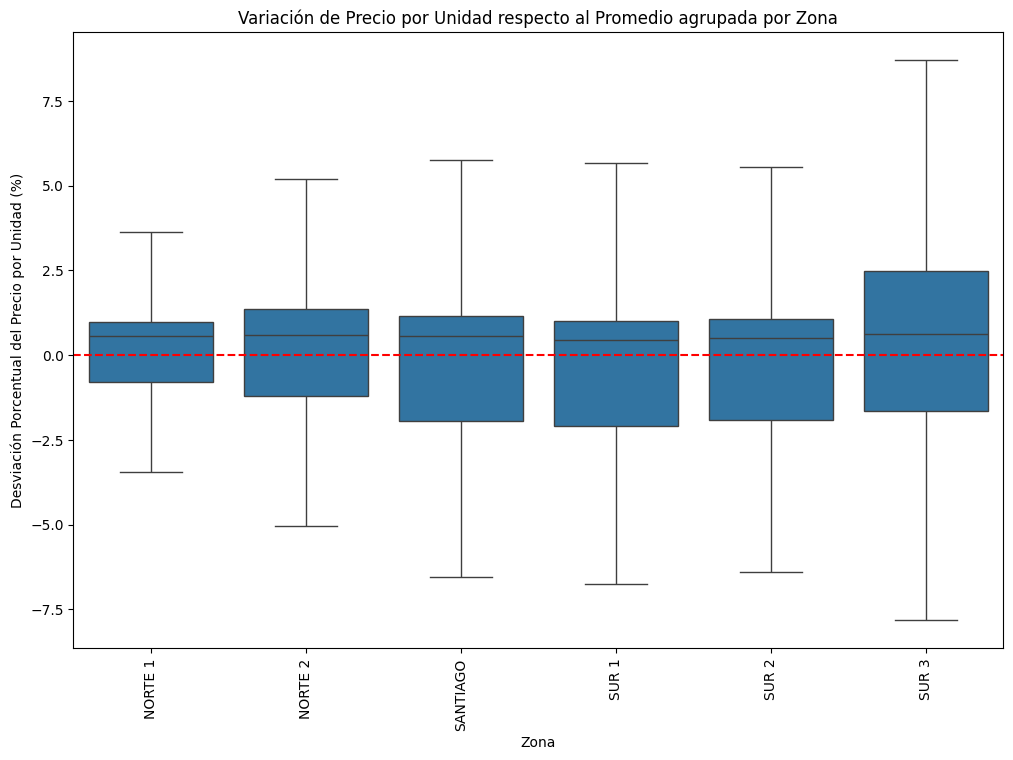

In [125]:
# Graficar variación de precio unitario c/r a precio promedio (como porcentaje) agrupando por Zona

datos_grafico = ventas[["zona", "desviacion_porcentual_precio_por_unidad"]].copy()

# Filtrar ventas con desviación porcentual extrema para evitar distorsionar el gráfico
datos_grafico = datos_grafico[
    (datos_grafico["desviacion_porcentual_precio_por_unidad"] < 100) &
    (datos_grafico["desviacion_porcentual_precio_por_unidad"] > -100)
]

# Convertir Zona a string por seguridad
datos_grafico["zona"] = datos_grafico["zona"].astype(str)

# Definir orden de zonas
orden_zonas = sorted(datos_grafico["zona"].dropna().unique())

plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    x="zona",
    y="desviacion_porcentual_precio_por_unidad",
    data=datos_grafico,
    order=orden_zonas,
    showfliers=False,
    #jitter=0.25,
    #alpha=0.6,
    #size=3
)

plt.axhline(0, color="red", linestyle="--")
plt.title("Variación de Precio por Unidad respecto al Promedio agrupada por Zona")
plt.xlabel("Zona")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(rotation=90)
plt.show()

## 2.2 Descuento con respecto a Precio Lista

In [126]:
# Agregar a ventas una columna que indique el porcentaje de descuento c/r al precio lista
ventas["descuento_por_unidad"] = (1 - ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) * 100
ventas["descuento"] = (1 - ventas["precio_real"] / ventas["precio_lista"]) * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,...,40.0,True,False,PUNTA ARENAS,1086.000,1153.80,1095.284329,-0.847664,5.876235,5.876235
1,1145633,CB,32,SUR 3,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,...,20.0,True,False,PUNTA ARENAS,1968.300,2036.34,1823.907855,7.916636,3.341289,3.341289
2,1173743,MY,38,NORTE 2,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,...,80.0,True,False,LA SERENA,4013.000,4395.50,4350.372971,-7.755036,8.702082,8.702082
3,1003766,CB,32,NORTE 2,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,...,1.0,True,False,LA SERENA,10860.000,11247.00,11190.369729,-2.952268,3.440918,3.440918
4,1037307,MY,57,SUR 2,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,...,16.0,True,False,CHILLAN,2308.625,2456.00,2280.189304,1.247076,6.000611,6.000611


In [127]:
# Comparar descuento_por_unidad con descuento real
ventas["diferencia_descuento"] = ventas["descuento_por_unidad"] - ventas["descuento"]

# Contar cuantas filas tienen diferencia significativa entre descuento_por_unidad y descuento real (ej. > 5 puntos porcentuales)
diferencia_significativa = ventas[np.abs(ventas["diferencia_descuento"]) > 1]
print("Número de filas con diferencia significativa entre descuento_por_unidad y descuento real:", diferencia_significativa.shape[0])

# Ver filas con diferencia significativa
diferencia_significativa["cod_sku"].value_counts()

Número de filas con diferencia significativa entre descuento_por_unidad y descuento real: 57


cod_sku
8508    13
3456     8
3032     7
6770     5
8043     3
2272     2
3313     2
3879     2
421      2
1020     2
6772     1
8284     1
1404     1
3922     1
8454     1
916      1
1433     1
1032     1
6777     1
738      1
3945     1
Name: count, dtype: int64

In [128]:
ventas = ventas[ventas["precio_lista"] > 0]
print(ventas.shape)
print(ventas[ventas["descuento"] < 0].shape)
print(ventas[ventas["descuento"] < -0.1].shape)
ventas[ventas["descuento"] < 0].sort_values("descuento").head()

(9851888, 26)
(2071301, 26)
(5663, 26)


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento,diferencia_descuento
117610,1137320,MY,57,NORTE 2,2025-05-15,1228,JAMON PLANCHADO SJ,30608,0.6,51013.333333,...,False,False,VIÑA DEL MAR,168344.000,17919.000,17746.722172,848.592074,-839.472069,-839.472069,0.000000e+00
7411998,1196805,CB,32,NORTE 2,2025-08-13,421,PATE TERNERA 8x125 GRS.SJ,9823,1.0,9823.000000,...,True,False,VIÑA DEL MAR,1227.875,484.750,482.580806,154.439253,-153.300670,-153.300670,0.000000e+00
8294316,1166369,CB,54,NORTE 1,2025-03-21,210,FIAMBRE SANDWICH SJ,7384,1.0,7384.000000,...,False,False,CALAMA,25829.232,12662.760,12575.225836,105.397759,-103.977901,-103.977901,0.000000e+00
216427,1236913,CB,32,SUR 1,2025-12-02,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38483,3.7,10400.810811,...,True,False,SAN FERNANDO,1924.150,1163.465,1022.565935,88.168795,-65.380996,-65.380996,-1.421085e-14
262300,1236913,CB,32,SUR 1,2025-12-09,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38482,3.7,10400.540541,...,True,False,SAN FERNANDO,1924.100,1163.465,1022.565935,88.163905,-65.376698,-65.376698,0.000000e+00


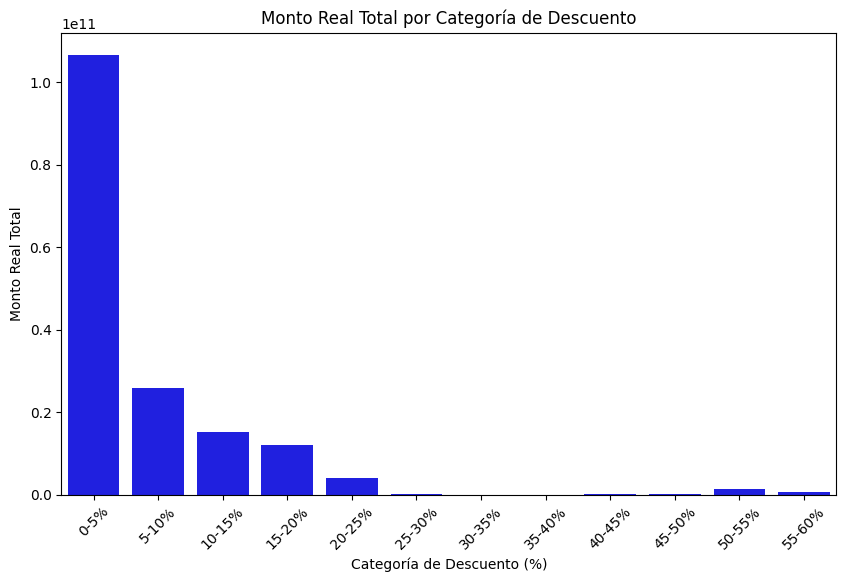

In [129]:
# Gráfico de columnas, una columna por cada 10% de descuento (0-10%, 10-20%, ..., 90-100%)
# En el eje x las categorías de descuento (0-10%, 10-20%, ..., 90-100%)
# En el eje y la cantidad de ventas en cada categoría, tomado como el monto real total de las ventas en cada categoría
largo_bins = 5
descuento_max = 60
bins = np.arange(0, descuento_max + largo_bins, largo_bins)
labels = [f"{i}-{i+largo_bins}%" for i in range(0, descuento_max, largo_bins)]

ventas["categoria_descuento"] = pd.cut(ventas["descuento"], bins=bins, right=False, labels=labels)
ventas_categoria = ventas.groupby("categoria_descuento")["monto_real"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="categoria_descuento", y="monto_real", data=ventas_categoria, color="blue")
plt.title("Monto Real Total por Categoría de Descuento")
plt.xlabel("Categoría de Descuento (%)")
plt.xticks(rotation=45)
plt.ylabel("Monto Real Total")
plt.show()

In [135]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado', 'zona',
       'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real', 'kilo_real',
       'precio_real', 'precio_lista', 'año_factura', 'mes_factura',
       'kg_por_unidad', 'peso_variable', 'cantidad_unidades',
       'cantidad_unidades_entera', 'inconsistencia', 'zonal',
       'precio_por_unidad', 'precio_lista_por_unidad',
       'precio_promedio_por_unidad', 'desviacion_porcentual_precio_por_unidad',
       'descuento_por_unidad', 'descuento', 'diferencia_descuento',
       'categoria_descuento'],
      dtype='str')

In [136]:
ventas["descuento_round"] = ventas["descuento"].round()

In [137]:
ventas[ventas["descuento_round"] == 0]["descuento"].describe()

count    6.634346e+06
mean     6.612347e-04
std      9.281939e-03
min     -4.672423e-01
25%     -2.578383e-03
50%      0.000000e+00
75%      2.964181e-03
max      4.511763e-01
Name: descuento, dtype: float64

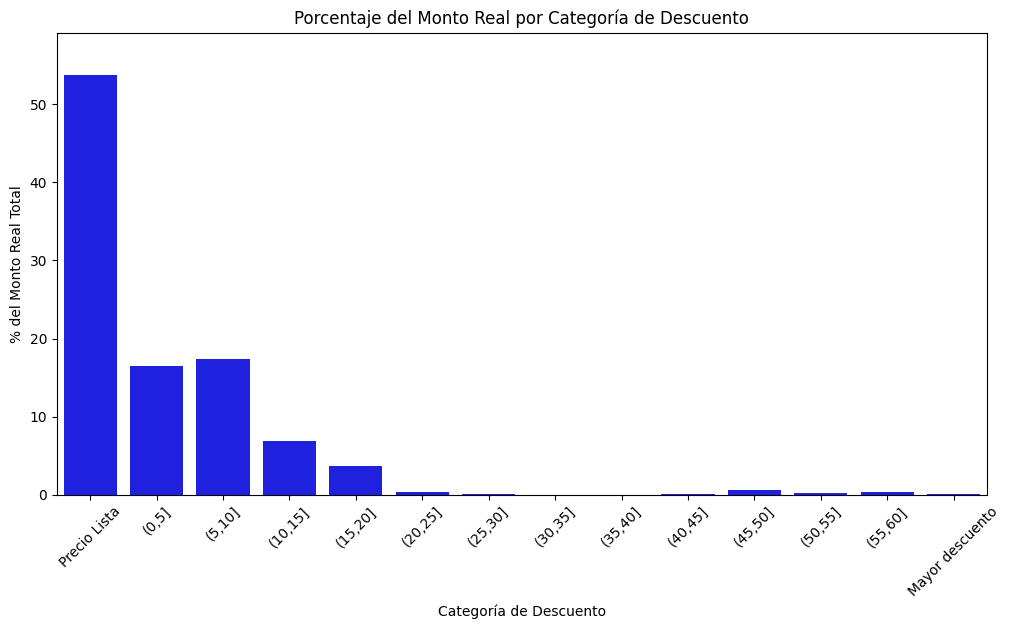

In [134]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

largo_bins = 5
descuento_max = 60

# Bordes de los intervalos:
# (-inf, 0], (0,5], (5,10], ..., (55,60], (60, inf)
bins = [-np.inf, 0] + list(np.arange(largo_bins, descuento_max + largo_bins, largo_bins)) + [np.inf]

# Etiquetas
labels = (
    ["Precio Lista"] +
    [f"({i},{i+largo_bins}]" for i in range(0, descuento_max, largo_bins)] +
    ["Mayor descuento"]
)

# Crear categoría de descuento
ventas["categoria_descuento"] = pd.cut(
    ventas["descuento"].round(),
    bins=bins,
    labels=labels,
    right=True,         # intervalos cerrados a la derecha: (a,b]
    include_lowest=True
)

# Sumar monto_real por categoría
ventas_categoria = (
    ventas.groupby("categoria_descuento", observed=False)["monto_real"]
    .sum()
    .reset_index()
)

# Convertir a porcentaje del monto real total
total_monto_real = ventas_categoria["monto_real"].sum()
ventas_categoria["porcentaje_monto_real"] = (
    ventas_categoria["monto_real"] / total_monto_real * 100
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    x="categoria_descuento",
    y="porcentaje_monto_real",
    data=ventas_categoria,
    color="blue"
)

plt.title("Porcentaje del Monto Real por Categoría de Descuento")
plt.xlabel("Categoría de Descuento")
plt.ylabel("% del Monto Real Total")
plt.xticks(rotation=45)
plt.ylim(0, ventas_categoria["porcentaje_monto_real"].max() * 1.1)
plt.show()

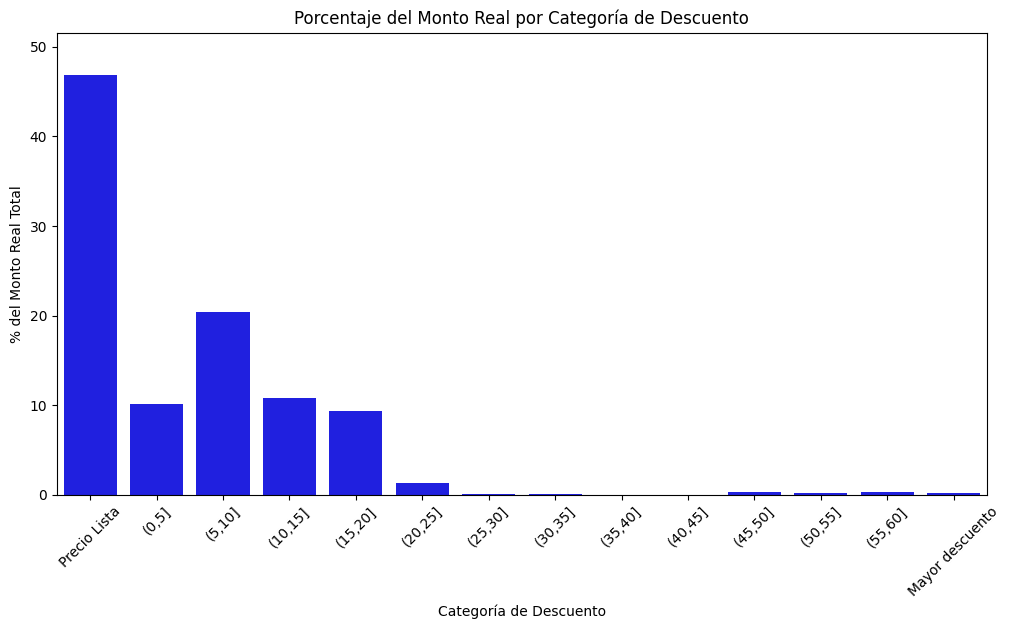

In [139]:
# Mismo gráfico pero con posibilidad de  filtrar año-mes
Años = [2026]
Meses = [1,2,3]

ventas_filtradas = ventas[ventas["año_factura"].isin(Años) & ventas["mes_factura"].isin(Meses)]

largo_bins = 5
descuento_max = 60

# Bordes de los intervalos:
# (-inf, 0], (0,5], (5,10], ..., (55,60], (60, inf)
bins = [-np.inf, 0] + list(np.arange(largo_bins, descuento_max + largo_bins, largo_bins)) + [np.inf]

# Etiquetas
labels = (
    ["Precio Lista"] +
    [f"({i},{i+largo_bins}]" for i in range(0, descuento_max, largo_bins)] +
    ["Mayor descuento"]
)

# Crear categoría de descuento
ventas_filtradas["categoria_descuento"] = pd.cut(
    ventas_filtradas["descuento"].round(),
    bins=bins,
    labels=labels,
    right=True,         # intervalos cerrados a la derecha: (a,b]
    include_lowest=True
)

# Sumar monto_real por categoría
ventas_categoria = (
    ventas_filtradas.groupby("categoria_descuento", observed=False)["monto_real"]
    .sum()
    .reset_index()
)

# Convertir a porcentaje del monto real total
total_monto_real = ventas_categoria["monto_real"].sum()
ventas_categoria["porcentaje_monto_real"] = (
    ventas_categoria["monto_real"] / total_monto_real * 100
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    x="categoria_descuento",
    y="porcentaje_monto_real",
    data=ventas_categoria,
    color="blue"
)

plt.title("Porcentaje del Monto Real por Categoría de Descuento")
plt.xlabel("Categoría de Descuento")
plt.ylabel("% del Monto Real Total")
plt.xticks(rotation=45)
plt.ylim(0, ventas_categoria["porcentaje_monto_real"].max() * 1.1)
plt.show()

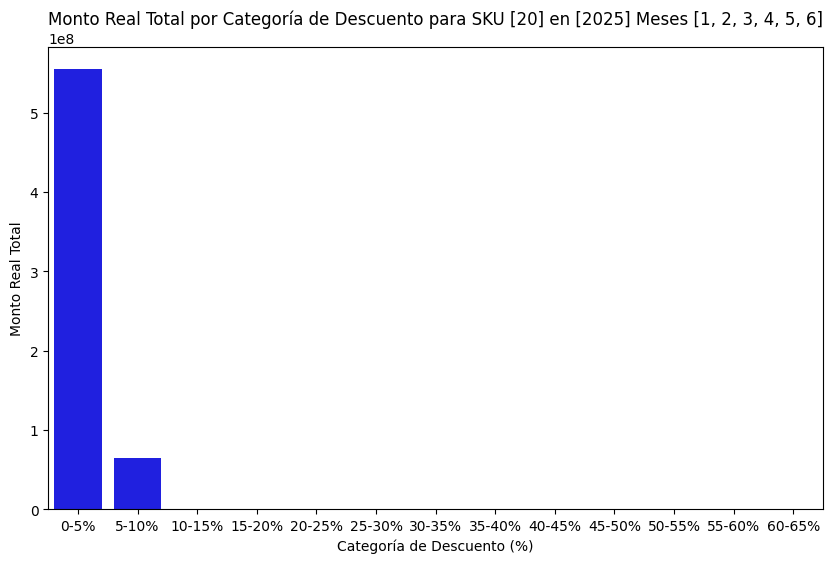

In [131]:
# Mismo gráfico anterior pero con posibilidad de filtrar año-mes de Fecha Factura y SKU
Años = [2025]
Meses = range(1, 7)
SKUs = [20]

ventas_filtradas = ventas[ventas["año_factura"].isin(Años) & ventas["mes_factura"].isin(Meses) & ventas["cod_sku"].isin(SKUs)]
ventas_filtradas["categoria_descuento"] = pd.cut(ventas_filtradas["descuento"], bins=np.arange(0, 70, 5), right=False, labels=[f"{i}-{i+5}%" for i in range(0, 65, 5)])
ventas_categoria_filtrada = ventas_filtradas.groupby("categoria_descuento")["monto_real"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="categoria_descuento", y="monto_real", data=ventas_categoria_filtrada, color="blue")
plt.title(f"Monto Real Total por Categoría de Descuento para SKU {SKUs} en {Años} Meses {list(Meses)}")
plt.xlabel("Categoría de Descuento (%)")
plt.ylabel("Monto Real Total")
plt.show()

# 3. Elasticidad

# 3.1. Elasticidad por SKU

# 3.2 Elasticidad por SKU-zona